📊 02_arxiv_keyword_trends.ipynb
Analysis Goal: Explore the annual paper trends and keyword focus changes for LLMs on Arxiv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import Markdown, display

1️⃣ Path Setup

In [2]:
DATA_PATH = Path("../data/raw/arxiv_trends_by_month.csv")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

print(f"Loading data file: {DATA_PATH}")

Loading data file: ..\data\raw\arxiv_trends_by_month.csv


2️⃣ Load and Initial Inspection

In [3]:
df = pd.read_csv(DATA_PATH)
display(df.head())

print(f"Total {len(df)} records, columns: {list(df.columns)}")

# Check columns
required_cols = {"year", "total_publications"}
if not required_cols.issubset(df.columns):
    raise ValueError(f"Missing columns: {required_cols - set(df.columns)}")

df["year"] = df["year"].astype(int)

,year,total_publications,alignment,efficiency,reasoning,prompt,chain-of-thought,RLHF,safety,robustness,...,knowledge,planning,coherence,memory,generalization,transfer learning,adversarial,optimization,performance,compression
0,2010,16,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,2,0
1,2011,32,0,0,2,0,0,0,0,0,...,3,0,0,2,1,0,0,1,4,4
2,2012,35,0,0,0,0,0,0,0,0,...,5,0,1,0,1,0,0,0,15,1
3,2013,52,0,0,0,0,0,0,0,1,...,1,1,1,2,1,1,0,2,17,0
4,2014,96,2,6,0,0,0,0,1,1,...,10,0,0,17,1,0,0,3,43,0


Total 16 records, columns: ['year', 'total_publications', 'alignment', 'efficiency', 'reasoning', 'prompt', 'chain-of-thought', 'RLHF', 'safety', 'robustness', 'scaling', 'few-shot', 'zero-shot', 'fine-tuning', 'instruction tuning', 'evaluation', 'capabilities', 'bias', 'fairness', 'hallucination', 'interpretability', 'reinforcement learning', 'RL', 'multi-modal', 'knowledge', 'planning', 'coherence', 'memory', 'generalization', 'transfer learning', 'adversarial', 'optimization', 'performance', 'compression']


3️⃣ Overall Paper Trend (by Year)

Saved: results/arxiv_yearly_trend.png


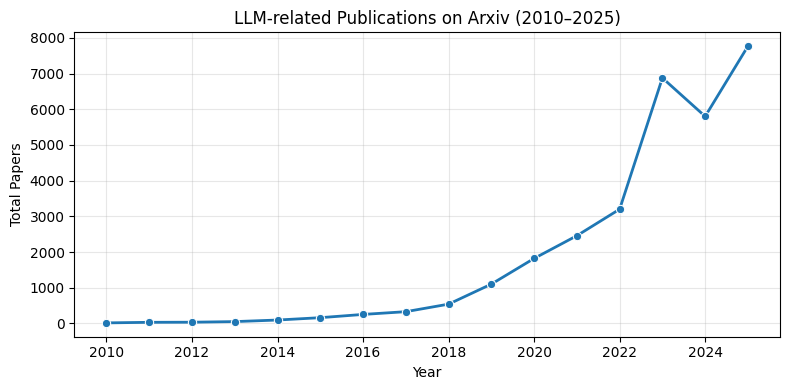

In [4]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=df, x="year", y="total_publications", marker="o", linewidth=2)
plt.title("LLM-related Publications on Arxiv (2010–2025)")
plt.xlabel("Year")
plt.ylabel("Total Papers")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "arxiv_yearly_trend.png", dpi=300)
print("Saved: results/arxiv_yearly_trend.png")
plt.show()

4️⃣ Keyword Trend Analysis

Saved: results/arxiv_keyword_trends.png


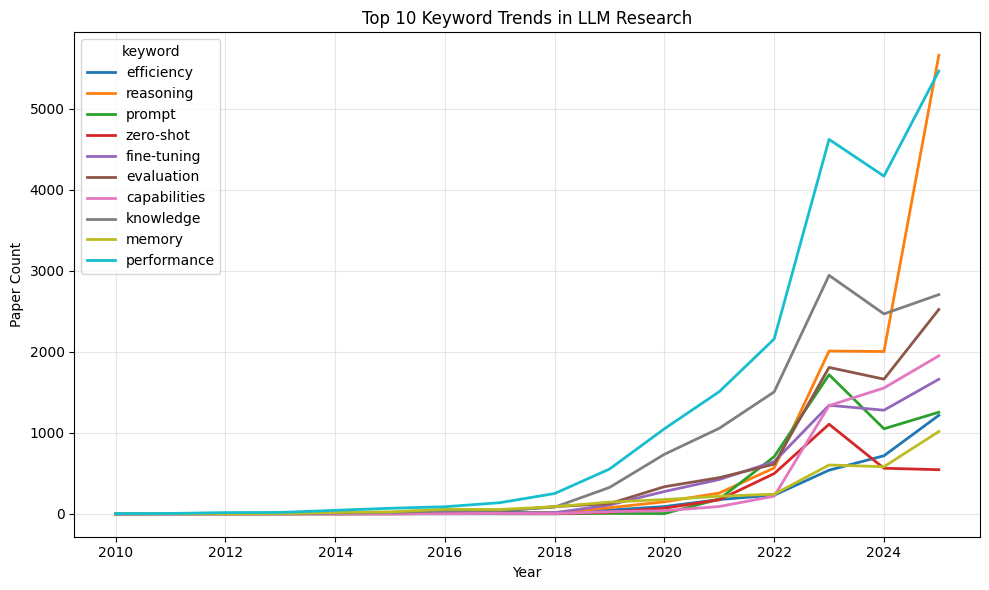

In [5]:
keyword_cols = [c for c in df.columns if c not in ["year", "total_publications"]]
if not keyword_cols:
    raise ValueError("Keyword columns not found")

melted = df.melt(id_vars=["year"], value_vars=keyword_cols,
                 var_name="keyword", value_name="count")

# Only display the top N keywords (e.g., top 10 with the highest average)
top_keywords = (
    melted.groupby("keyword")["count"]
    .mean().sort_values(ascending=False).head(10).index.tolist()
)
top_df = melted[melted["keyword"].isin(top_keywords)]

plt.figure(figsize=(10, 6))
sns.lineplot(data=top_df, x="year", y="count", hue="keyword", linewidth=2)
plt.title("Top 10 Keyword Trends in LLM Research")
plt.xlabel("Year")
plt.ylabel("Paper Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "arxiv_keyword_trends.png", dpi=300)
print("Saved: results/arxiv_keyword_trends.png")
plt.show()

5️⃣ Keyword Share Analysis

Saved: results/arxiv_keyword_share.png


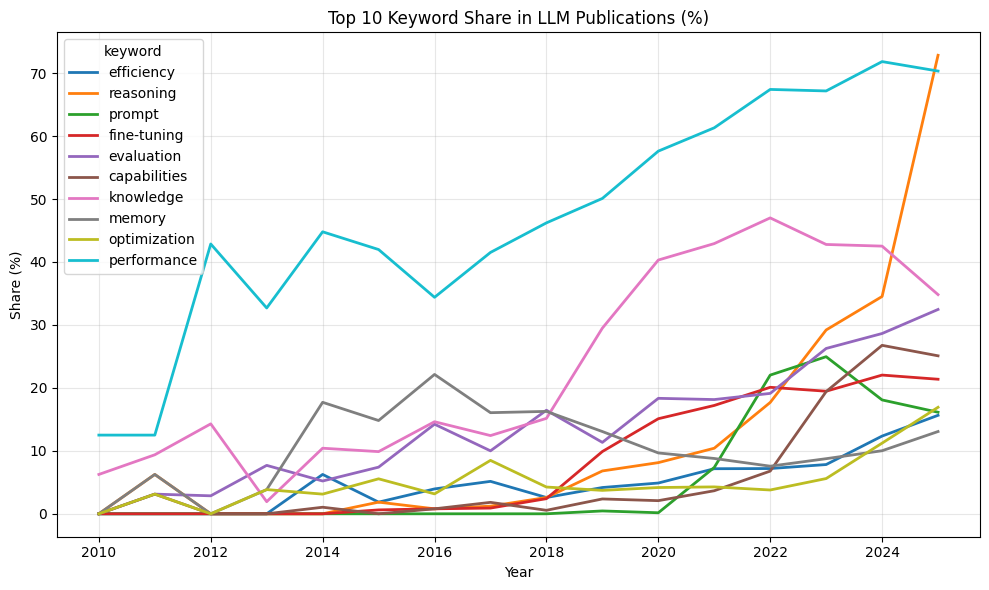

In [6]:
for kw in keyword_cols:
    share_col = f"{kw}_share"
    df[share_col] = df[kw] / df["total_publications"] * 100

share_cols = [c for c in df.columns if c.endswith("_share")]
share_melt = df.melt(id_vars=["year"], value_vars=share_cols,
                       var_name="keyword", value_name="share")
share_melt["keyword"] = share_melt["keyword"].str.replace("_share", "")

top_share = (
    share_melt.groupby("keyword")["share"]
    .mean().sort_values(ascending=False).head(10).index.tolist()
)
top_share_df = share_melt[share_melt["keyword"].isin(top_share)]

plt.figure(figsize=(10, 6))
sns.lineplot(data=top_share_df, x="year", y="share", hue="keyword", linewidth=2)
plt.title("Top 10 Keyword Share in LLM Publications (%)")
plt.xlabel("Year")
plt.ylabel("Share (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "arxiv_keyword_share.png", dpi=300)
print("Saved: results/arxiv_keyword_share.png")
plt.show()

6️⃣ Brief Summary Output

In [7]:
growth = df["total_publications"].iloc[-1] / df["total_publications"].iloc[0]
peak_year = df.loc[df["total_publications"].idxmax(), "year"]

dominant_kw = (
    share_melt.groupby("keyword")["share"]
    .mean().sort_values(ascending=False).index[0]
)

summary_md = f"""
## Arxiv Annual Trend and Keyword Analysis Summary

- Time Span: {df['year'].min()} – {df['year'].max()}
- Annual paper growth is approximately **{growth:.1f} times**
- Peak number of papers occurred in **{peak_year}**
- Total number of core research direction keywords: {len(keyword_cols)}
- The topic with the highest average share is **{dominant_kw}**
- Key Results:
  - `results/arxiv_yearly_trend.png`: Overall paper trend
  - `results/arxiv_keyword_trends.png`: Keyword trends (Top 10)
  - `results/arxiv_keyword_share.png`: Keyword share change (Top 10)
"""
display(Markdown(summary_md))


## Arxiv Annual Trend and Keyword Analysis Summary

- Time Span: 2010 – 2025
- Annual paper growth is approximately **485.4 times**
- Peak number of papers occurred in **2025**
- Total number of core research direction keywords: 32
- The topic with the highest average share is **performance**
- Key Results:
  - `results/arxiv_yearly_trend.png`: Overall paper trend
  - `results/arxiv_keyword_trends.png`: Keyword trends (Top 10)
  - `results/arxiv_keyword_share.png`: Keyword share change (Top 10)
